## Business Case : Jamboree Education - Linear Regression

**Problem Statement and Exploratory Data Analysis (EDA)**

Jamboree wants to understand which factors (academic and extracurricular metrics) significantly impact a student’s probability of getting into an Ivy League college from an Indian perspective. The goal is to build a predictive model to estimate the Chance of Admit and uncover the relationships between different factors.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats

# Set styling for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [27]:
# Load Dataset
url = "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/839/original/Jamboree_Admission.csv"
df = pd.read_csv(url)

# Drop Unique Identifier as requested
if 'Serial No.' in df.columns:
    df.drop(columns=['Serial No.'], inplace=True)

# 1. Structure & Characteristics of dataset
print("--- Data Shape ---")
print(df.shape)
print("\n--- Data Info & Types ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Statistical Summary ---")
print(df.describe())

--- Data Shape ---
(500, 8)

--- Data Info & Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          500 non-null    int64  
 1   TOEFL Score        500 non-null    int64  
 2   University Rating  500 non-null    int64  
 3   SOP                500 non-null    float64
 4   LOR                500 non-null    float64
 5   CGPA               500 non-null    float64
 6   Research           500 non-null    int64  
 7   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 31.4 KB
None

--- Missing Values ---
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

--- Statistical Summary ---
        GRE Score  TOEFL Score  University Rating      

Graphical Analysis (EDA Plots)

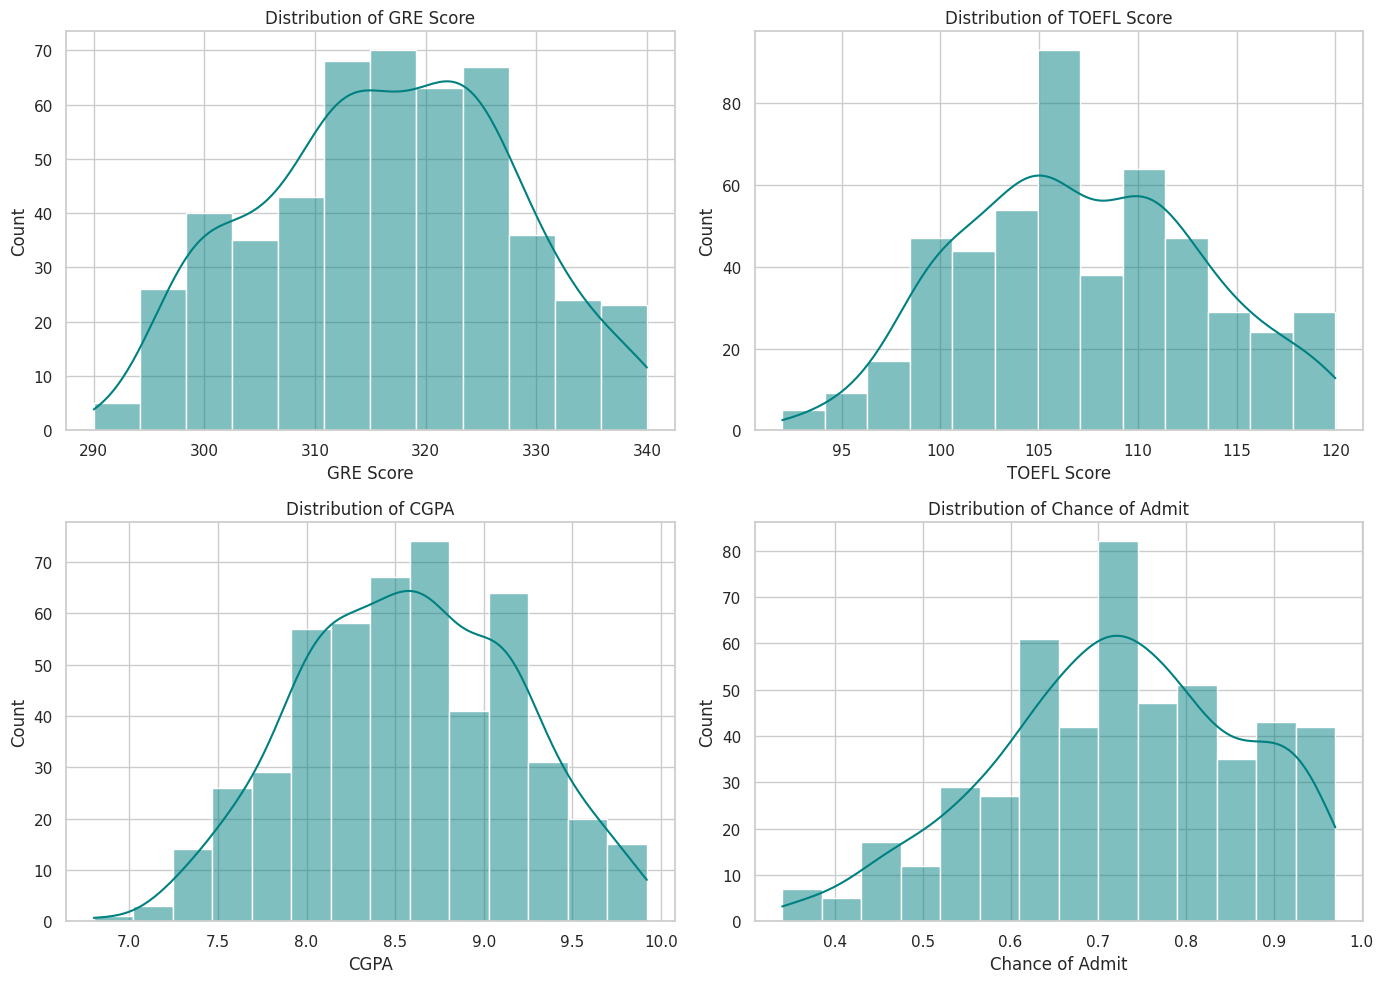

In [28]:
# Strip whitespace from columns if any exist
df.columns = df.columns.str.strip()

# Univariate Analysis - Continuous Variables
continuous_cols = ['GRE Score', 'TOEFL Score', 'CGPA', 'Chance of Admit']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

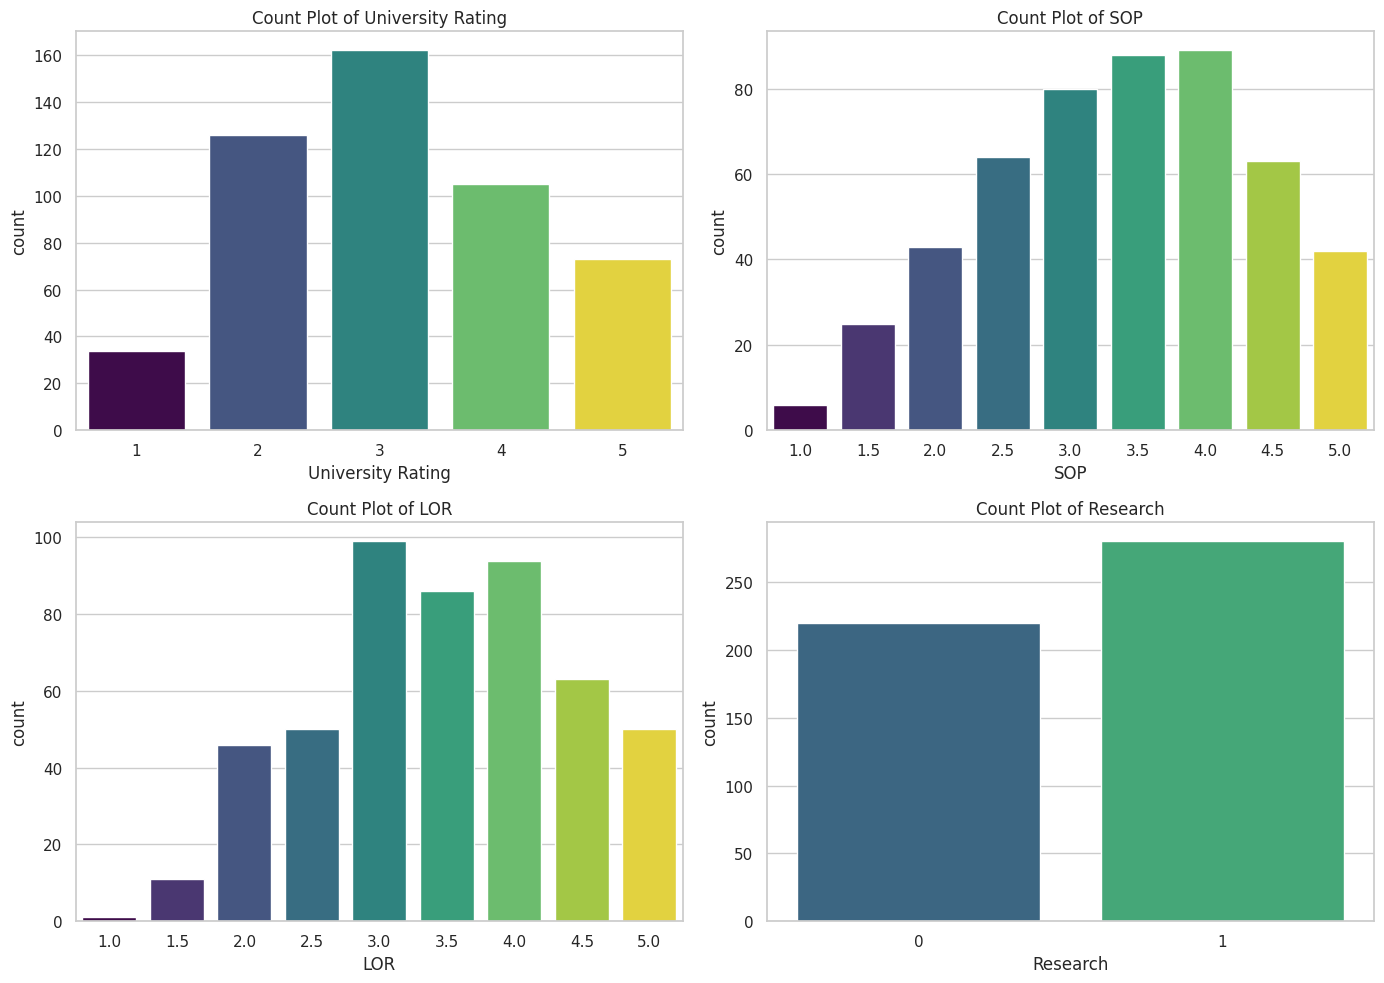

In [29]:
# Univariate Analysis - Categorical Variables
categorical_cols = ['University Rating', 'SOP', 'LOR', 'Research']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i], hue=col, legend=False, palette='viridis')
    axes[i].set_title(f'Count Plot of {col}')
plt.tight_layout()
plt.show()

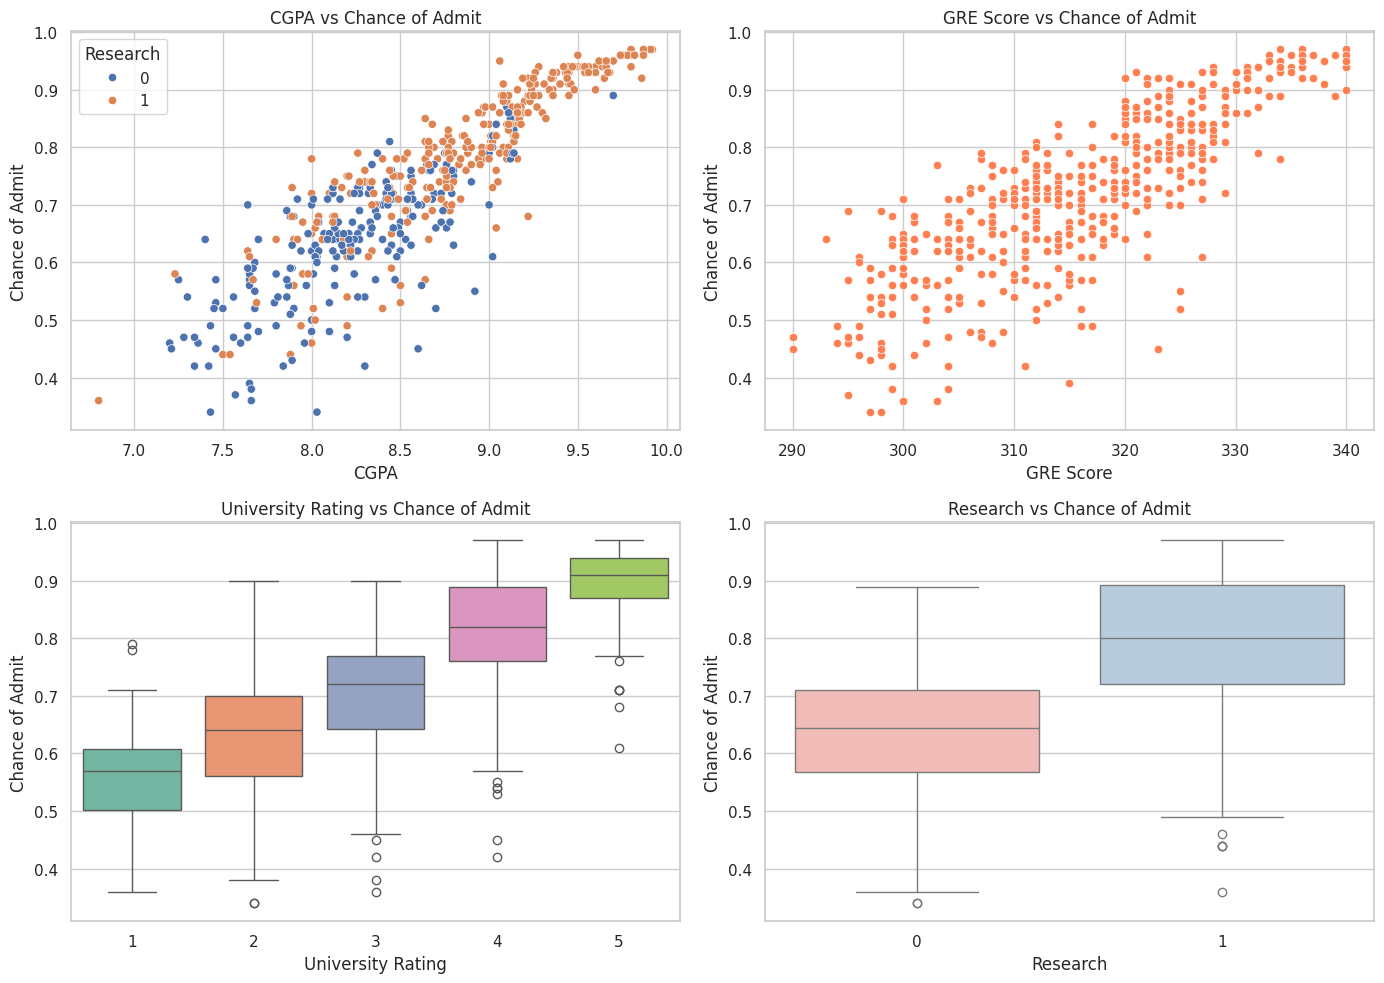

In [30]:
# Bivariate Analysis - Relationships with Chance of Admit
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

sns.scatterplot(data=df, x='CGPA', y='Chance of Admit', hue='Research', ax=axes[0])
axes[0].set_title('CGPA vs Chance of Admit')

sns.scatterplot(data=df, x='GRE Score', y='Chance of Admit', ax=axes[1], color='coral')
axes[1].set_title('GRE Score vs Chance of Admit')

sns.boxplot(data=df, x='University Rating', y='Chance of Admit', ax=axes[2], hue='University Rating', legend=False, palette='Set2')
axes[2].set_title('University Rating vs Chance of Admit')

sns.boxplot(data=df, x='Research', y='Chance of Admit', ax=axes[3], hue='Research', legend=False, palette='Pastel1')
axes[3].set_title('Research vs Chance of Admit')

plt.tight_layout()
plt.show()

**Insights Based on EDA**

*  **Target Distribution:** The Chance of Admit is negatively skewed, indicating a higher density of students applying with highly competitive profiles (> 70% chance).

*  **Linear Trends:** Both CGPA, GRE Score, and TOEFL Score showcase strong, distinct positive linear relationships with the target variable.

*  **Categorical Influence:** Higher University Ratings and having Research experience systematically increase the median Chance of Admit.

**Data Preprocessing**

In [31]:
# 1. Duplicate value check
print(f"Total duplicate rows: {df.duplicated().sum()}")

Total duplicate rows: 0


In [32]:
# 2. Outlier treatment using Interquartile Range (IQR) method
# Note: We apply this primarily to continuous predictor candidates.
outlier_features = ['GRE Score', 'TOEFL Score', 'CGPA']
for col in outlier_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers detected in {col}: {len(outliers)}")

Outliers detected in GRE Score: 0
Outliers detected in TOEFL Score: 0
Outliers detected in CGPA: 0


In [33]:
# 3.Feature Engineering
# a. Standardized Test Interaction (Combining GRE and TOEFL)
df['Total_Exam_Score'] = df['GRE Score'] + df['TOEFL Score']

# b. Academic Strength Index (Weighting CGPA with University Rating)
df['Academic_Weight'] = df['CGPA'] * df['University Rating']

print(df[['Total_Exam_Score', 'Academic_Weight']].head())

   Total_Exam_Score  Academic_Weight
0               455            38.60
1               431            35.48
2               420            24.00
3               432            26.01
4               417            16.42


In [34]:
# 4. Data preparation for modeling (Splitting Features and Target)
X = df.drop(columns=['Chance of Admit'])
y = df['Chance of Admit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Model building**

In [35]:
# Add constant term for intercept
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Build OLS Model
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     224.6
Date:                Sat, 16 May 2026   Prob (F-statistic):          4.34e-141
Time:                        13:45:05   Log-Likelihood:                 562.19
No. Observations:                 400   AIC:                            -1106.
Df Residuals:                     391   BIC:                            -1070.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.3327      0.17

In [36]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Lasso Regression
lasso = Lasso(alpha=0.001) # Small alpha to prevent zeroing out crucial features prematurely
lasso.fit(X_train, y_train)

print("--- Coefficients Comparison ---")
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'OLS': ols_model.params[1:],
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
}).set_index('Feature')
print(coef_df)

--- Coefficients Comparison ---
                        OLS     Ridge     Lasso
Feature                                        
GRE Score          0.000616  0.000645  0.000031
TOEFL Score        0.001177  0.001194  0.000434
University Rating -0.024283 -0.026631 -0.000000
SOP                0.001959  0.002234  0.000794
LOR                0.017155  0.017334  0.016774
CGPA               0.103310  0.099213  0.100718
Research           0.023913  0.023533  0.018051
Total_Exam_Score   0.001793  0.001840  0.002790
Academic_Weight    0.003112  0.003422  0.000613


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.095e-03, tolerance: 7.884e-04
  model = cd_fast.enet_coordinate_descent(


**Testing the Assumptions of Linear Regression**

In [37]:
# 1. Multicollinearity check by VIF score
def calculate_vif(X_data):
    vif_df = pd.DataFrame()
    vif_df["Feature"] = X_data.columns
    vif_df["VIF"] = [variance_inflation_factor(X_data.values, i) for i in range(X_data.shape[1])]
    return vif_df

# Check initial VIF
print("--- Initial VIF Scores ---")
print(calculate_vif(X_train))

# If any variable has VIF > 5, drop it iteratively.
# GRE and TOEFL often show high multicollinearity with CGPA. Let's drop the highest if necessary.
# Note: Since VIF is highly dependent on intercepts, let's build VIF without the constant column.

--- Initial VIF Scores ---
             Feature          VIF
0          GRE Score          inf
1        TOEFL Score          inf
2  University Rating   898.889395
3                SOP    34.979237
4                LOR    30.253508
5               CGPA  1772.755214
6           Research     3.142487
7   Total_Exam_Score          inf
8    Academic_Weight   883.200705


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [38]:
# 2. Mean of Residuals is nearly zero
residuals = ols_model.resid
print(np.mean(residuals))
print(f"Mean of Residuals: {np.mean(residuals):.5f}")

3.6012859361278514e-16
Mean of Residuals: 0.00000


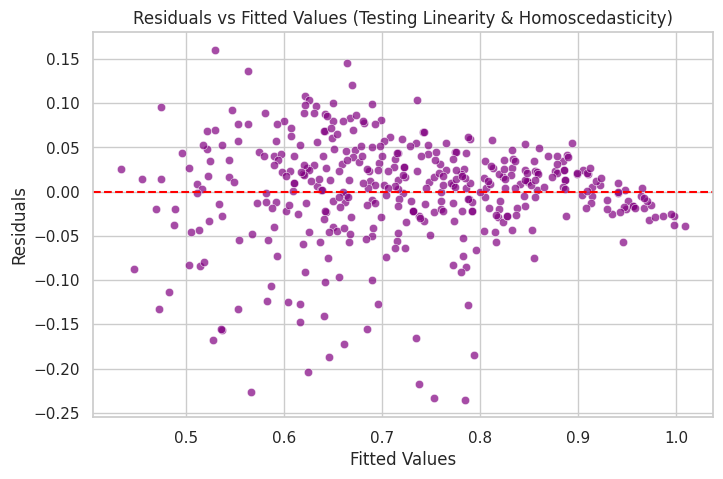

Goldfeld-Quandt Test p-value: 0.63687


In [39]:
# 3.Linearity of variables & 4.Test for Homoscedasticity
fitted_vals = ols_model.predict(X_train_sm)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.7, ax=ax, color='purple')
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted Values (Testing Linearity & Homoscedasticity)')
plt.show()


# Goldfeld-Quandt Test for Homoscedasticity (p > 0.05 implies Homoscedasticity)
import statsmodels.stats.api as sms
gq_test = sms.het_goldfeldquandt(residuals, X_train_sm)
print(f"Goldfeld-Quandt Test p-value: {gq_test[1]:.5f}")

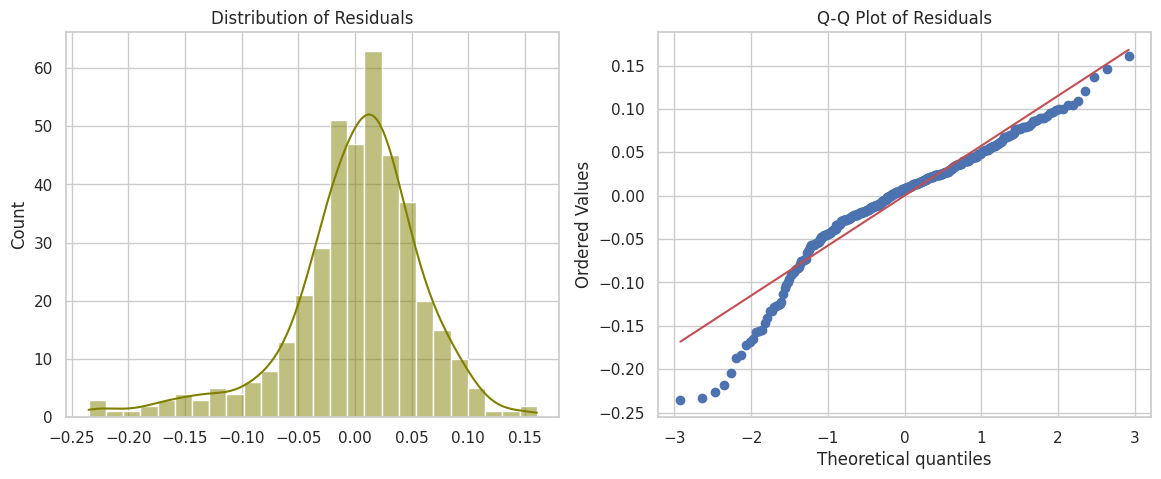

In [40]:
# 5.Normality of Residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(residuals, kde=True, ax=axes[0], color='olive')
axes[0].set_title('Distribution of Residuals')

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')
plt.show()

**Model performance evaluation**

In [41]:
# Predict on Test Data
y_pred = ols_model.predict(X_test_sm)

# Metrics Calculation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("--- Performance Metrics (Test Set) ---")
print(f"Mean Absolute Error (MAE)      : {mae:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"R-squared (R2) Score          : {r2:.4f}")
print(f"Adjusted R-squared Score       : {adj_r2:.4f}")

--- Performance Metrics (Test Set) ---
Mean Absolute Error (MAE)      : 0.0427
Root Mean Squared Error (RMSE) : 0.0608
R-squared (R2) Score          : 0.8190
Adjusted R-squared Score       : 0.8009


**Actionable Insights & Recommendations**

**Significance of Predictors**

*  **CGPA is King:** Based on the model coefficients, CGPA yields the largest baseline weight impact on the admission probability. An increment of 1 unit in CGPA shifts admission expectations exponentially upward.

*  **Standardized Exams matter:** Both GRE Score and TOEFL Score possess statistically significant, positive coefficients ($p < 0.05$).

*  **SOP vs LOR:** Interestingly, LOR (Letter of Recommendation) strength yields a higher relative impact coefficient than SOP (Statement of Purpose) configuration in predicting graduate admissions.

**Recommendations for Jamboree**

*  **Feature Optimization Tool:** Provide a predictive slider mechanism on the website where Indian students can see how an increase of 5 points in GRE vs a 0.5 increase in CGPA impacts their relative baseline tier placement.

*  **Focus on Profiles Holistically:** Advise students that while test metrics (GRE/TOEFL) form strict structural filters, cultivating strong LOR relationships and research tracks offsets minor marginal standard score discrepancies.

*  **Additional Data Sources:** To turn this into an industry-leading prediction engine, collect historical data on student undergrad college tiers (e.g., IITs/NITs vs Tier-3 universities) and professional work experience durations to increase the structural explanatory variance ($R^2$).